In [264]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import iqr
plt.rcParams["figure.figsize"] = (5,3)
student_alc = pd.read_csv("../ZDatasets/student-alcohol-consumption.csv", index_col=0)

# Explanatory Data Analysis
The process of reviweing and cleaning data to
- derive insights
- generate hypotheses

In [265]:
# Inspect the dataset
student_alc.head()

,school,sex,age,famsize,Pstatus,Medu,Fedu,traveltime,failures,schoolsup,...,goout,Dalc,Walc,health,absences,G1,G2,G3,location,study_time
0,GP,F,18,GT3,A,4,4,2,0,yes,...,4,1,1,3,6,5,6,6,Urban,2 to 5 hours
1,GP,F,17,GT3,T,1,1,1,0,no,...,3,1,1,3,4,5,5,6,Urban,2 to 5 hours
2,GP,F,15,LE3,T,1,1,1,3,yes,...,2,2,3,3,10,7,8,10,Urban,2 to 5 hours
3,GP,F,15,GT3,T,4,2,1,0,no,...,2,1,1,5,2,15,14,15,Urban,5 to 10 hours
4,GP,F,16,GT3,T,3,3,1,0,no,...,2,1,2,5,4,6,10,10,Urban,2 to 5 hours


## 1. First Look
### 1.1 Gathering more info

In [266]:
student_alc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395 entries, 0 to 394
Data columns (total 29 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   famsize     395 non-null    object
 4   Pstatus     395 non-null    object
 5   Medu        395 non-null    int64 
 6   Fedu        395 non-null    int64 
 7   traveltime  395 non-null    int64 
 8   failures    395 non-null    int64 
 9   schoolsup   395 non-null    object
 10  famsup      395 non-null    object
 11  paid        395 non-null    object
 12  activities  395 non-null    object
 13  nursery     395 non-null    object
 14  higher      395 non-null    object
 15  internet    395 non-null    object
 16  romantic    395 non-null    object
 17  famrel      395 non-null    int64 
 18  freetime    395 non-null    int64 
 19  goout       395 non-null    int64 
 20  Dalc        395

### 1.2 Closer look at categorical columns

In [267]:
# value_counts of 'location'
student_alc['location'].value_counts()

location
Urban    307
Rural     88
Name: count, dtype: int64

### 1.3 Closer look at numerical columns

In [268]:
# Count, Mean, Std, Min, 25-75% percentile, max of the whole dataset
student_alc.describe()

,age,Medu,Fedu,traveltime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


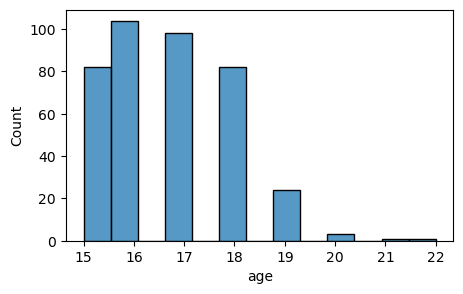

In [269]:
### 1.4 Visualising numerical data to understnad their distribution (normal, skewed)
sns.histplot(data = student_alc, x = 'age') # bins or binwidth adjustable
plt.show()

## 2 Data validation

### 2.1 Validating data types

In [270]:
student_alc.dtypes

school        object
sex           object
age            int64
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
traveltime     int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
location      object
study_time    object
dtype: object

#### Updating data types

In [271]:
student_alc[['sex','schoolsup']] = student_alc[['sex','schoolsup']].astype('category')
student_alc[['sex','schoolsup']].dtypes

sex          category
schoolsup    category
dtype: object

### 2.2 Validating categorical data

In [272]:
# No entries differ from sex == male or female
student_alc[~student_alc['sex'].isin(['M','F'])]

,school,sex,age,famsize,Pstatus,Medu,Fedu,traveltime,failures,schoolsup,...,goout,Dalc,Walc,health,absences,G1,G2,G3,location,study_time


### 2.3 Validating numerical data

In [273]:
student_alc.select_dtypes("number").head()

,age,Medu,Fedu,traveltime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,18,4,4,2,0,4,3,4,1,1,3,6,5,6,6
1,17,1,1,1,0,5,3,3,1,1,3,4,5,5,6
2,15,1,1,1,3,4,3,2,2,3,3,10,7,8,10
3,15,4,2,1,0,3,2,2,1,1,5,2,15,14,15
4,16,3,3,1,0,4,3,2,1,2,5,4,6,10,10


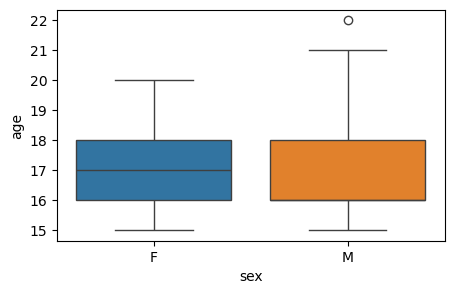

In [274]:
# Visualise numerical values
sns.boxplot(data = student_alc, x = 'sex', y = 'age', hue= 'sex')
plt.show()

## 3. Data summarisation

### 3.1 Exploring groups data by category

In [275]:
student_alc[['sex','traveltime','failures']].groupby('sex').agg(['mean','std'])

/var/folders/bh/_p1bkhtn09b6syd7vz5f61pw0000gn/T/ipykernel_14196/2719446205.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  student_alc[['sex','traveltime','failures']].groupby('sex').agg(['mean','std'])


traveltime            failures          
          mean       std      mean       std
sex                                         
F     1.408654  0.645551  0.302885  0.701683
M     1.491979  0.750405  0.368984  0.788152

## 4. Converting and analyzing categorical data
### 4.1 First glance

In [276]:
# Previewing the data
student_alc.select_dtypes('object').head()

,school,famsize,Pstatus,famsup,paid,activities,nursery,higher,internet,romantic,location,study_time
0,GP,GT3,A,no,no,no,yes,yes,no,no,Urban,2 to 5 hours
1,GP,GT3,T,yes,no,no,no,yes,yes,no,Urban,2 to 5 hours
2,GP,LE3,T,no,yes,no,yes,yes,yes,no,Urban,2 to 5 hours
3,GP,GT3,T,yes,yes,yes,yes,yes,yes,yes,Urban,5 to 10 hours
4,GP,GT3,T,yes,yes,no,yes,yes,no,no,Urban,2 to 5 hours


In [277]:
# Unique values
print(f"Unique Schools: {student_alc['school'].nunique()}")
# Values per subgroup
student_alc['study_time'].value_counts()

Unique Schools: 2


study_time
2 to 5 hours     198
<2 hours         105
5 to 10 hours     65
>10 hours         27
Name: count, dtype: int64

### 4.2 Extracting value from categories
- Search a column for a specific string or multiple strings
- *pandas.Series.str.container()*
- *.str.contains("string1|string2")* # Look for two string conditions
- *.str.contains("^string1")* # Any strings that start with Data

In [278]:
student_alc[student_alc['location'].str.contains("Urban")].head()

,school,sex,age,famsize,Pstatus,Medu,Fedu,traveltime,failures,schoolsup,...,goout,Dalc,Walc,health,absences,G1,G2,G3,location,study_time
0,GP,F,18,GT3,A,4,4,2,0,yes,...,4,1,1,3,6,5,6,6,Urban,2 to 5 hours
1,GP,F,17,GT3,T,1,1,1,0,no,...,3,1,1,3,4,5,5,6,Urban,2 to 5 hours
2,GP,F,15,LE3,T,1,1,1,3,yes,...,2,2,3,3,10,7,8,10,Urban,2 to 5 hours
3,GP,F,15,GT3,T,4,2,1,0,no,...,2,1,1,5,2,15,14,15,Urban,5 to 10 hours
4,GP,F,16,GT3,T,3,3,1,0,no,...,2,1,2,5,4,6,10,10,Urban,2 to 5 hours


### 4.3 Creating the categorical column

In [279]:
# Get data
salaries = pd.read_csv("../ZDatasets/ds_salaries_clean.csv")

job_categories = ["Data Science", "Data Analytics", "Data Engineering", "Machine Learning",
                  "Managerial", "Consultant"]

In [280]:
# Finding multiple phrases in strings
data_science = "Data Science|NLP"
data_analyst = "Analyst|Analytics"
data_engineer = "Data Engineer|ETL|Architect|Infrastructure"
ml_engineer = "Machine Learning|ML|Big Data|AI"
manager = "Manager|Head|Director|Lead|Principle|Staff"
consultant = "Consultant|Freelance"

# Creating the condition
conditions = [
    (salaries["Designation"].str.contains(data_science)),
    (salaries["Designation"].str.contains(data_analyst)),
    (salaries["Designation"].str.contains(data_engineer)),
    (salaries["Designation"].str.contains(ml_engineer)),
    (salaries["Designation"].str.contains(manager)),
    (salaries["Designation"].str.contains(consultant)),
]

In [281]:
# Creating the categorical column
salaries['Job_Category'] = np.select(conditions,
                                     job_categories,
                                     default = "Other")

In [282]:
salaries.head()

,Working_Year,Designation,Experience,Employment_Status,Employee_Location,Company_Size,Remote_Working_Ratio,Salary_USD,Job_Category
0,2020,Data Scientist,Mid,FT,DE,L,0,76227.0,Other
1,2020,Machine Learning Scientist,Senior,FT,JP,S,0,248257.0,Machine Learning
2,2020,Big Data Engineer,Senior,FT,GB,M,50,104100.0,Data Engineering
3,2020,Product Data Analyst,Mid,FT,HN,S,0,19097.0,Data Analytics
4,2020,Machine Learning Engineer,Senior,FT,US,L,50,143225.0,Machine Learning


## 5. Workig with numeric data
### 5.1 Converting strings to numbers
*pd.Series.str.replace("characters to remove", "characters to replace them with")*

In [283]:
# If the columns contains a symbol
salaries['Salary_USD'] = salaries['Salary_USD'].astype("str").add("$")

In [284]:
# Remove the dollar sign to work with salary
salaries["Salary_USD"] = salaries["Salary_USD"].str.replace("$","").astype('float')
salaries["Salary_USD"].head()

0     76227.0
1    248257.0
2    104100.0
3     19097.0
4    143225.0
Name: Salary_USD, dtype: float64

### 5.2 Adding summary statistics into a Dataframe
1. Group by Experience -> Select "Salary_USD"
2. Call *transform()* -> Apply lambda function

In [285]:
salaries['std_dev'] = salaries.groupby('Experience')['Salary_USD'].transform(lambda x: x.std())
salaries[['Experience','std_dev']].value_counts()

Experience  std_dev      
Senior      55086.264071     280
Mid         61014.876754     213
Entry       42390.355189      88
Executive   111783.576779     26
Name: count, dtype: int64

## 6. Finding outliers
- Outlier: An observation far away from other data points
- To find it: We subset the column for values under *Lower Limit* and above the *Upper Limit*.
- *IQR* = 75th percentile - 25th percentile
- *Lower Limit* = < 25th percentile - 1.5 * iqr
- *Upper Limit* = > 75th percentile + 1.5 * iqr

In [286]:
iqr = iqr(student_alc['age'])
lower_threshold = np.quantile(student_alc['age'], 0.25) - 1.5 * iqr
upper_threshold = np.quantile(student_alc['age'], 0.75) + 1.5 * iqr
student_alc[(student_alc['age'] < lower_threshold) | (student_alc['age'] > upper_threshold)]

# Alternatively: student['age'].describe()

,school,sex,age,famsize,Pstatus,Medu,Fedu,traveltime,failures,schoolsup,...,goout,Dalc,Walc,health,absences,G1,G2,G3,location,study_time
247,GP,M,22,GT3,T,3,1,1,3,no,...,5,5,5,1,16,6,8,8,Urban,<2 hours


### 6.1 IQR in box plots

<Axes: ylabel='Salary_USD'>

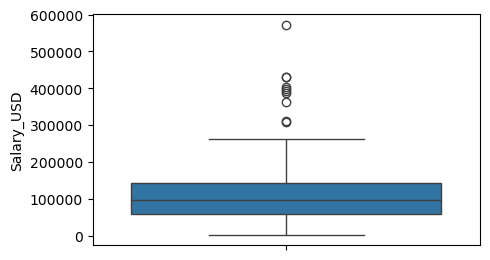

In [287]:
sns.boxplot(data = salaries, y = 'Salary_USD')

### 6.2 Identifying thresholds

In [288]:
# 75th percentile
seventy_fifth = salaries["Salary_USD"].quantile(0.75)
# 25th percentile
twenty_fifth = salaries["Salary_USD"].quantile(0.25)
# Interquartile range
salaries_iqr = seventy_fifth - twenty_fifth
# Thresholds
upper = seventy_fifth + (1.5 * salaries_iqr)
lower = twenty_fifth - (1.5 * salaries_iqr)

# Subsetting our data
salaries[(salaries['Salary_USD'] < lower) | (salaries['Salary_USD'] > upper)]\
    [["Experience", "Employee_Location", "Salary_USD"]].head()

,Experience,Employee_Location,Salary_USD
25,Executive,US,310321.0
33,Mid,US,429675.0
63,Senior,US,393392.0
97,Mid,US,429675.0
157,Mid,US,403895.0


### 6.3 Why looking for Outliers
- Outliers are extreme values and may not accurately represent our data
- Can change the mean and standard deviation
- Statistical tests and machine learning models need normally distributed data
- _Remove IF_: Data is an error
- **Ask why those outlier exist**

### 6.4 Dropping outliers

In [289]:
no_outliers = salaries[(salaries['Salary_USD'] > lower) & (salaries['Salary_USD'] < upper)]
no_outliers.describe()

,Working_Year,Remote_Working_Ratio,Salary_USD,std_dev
count,597.000000,597.000000,597.000000,597.000000
mean,2021.412060,70.686767,102328.480737,57389.630170
std,0.688634,40.797800,55910.790653,12228.188795
min,2020.000000,0.000000,2730.000000,42390.355189
25%,2021.000000,50.000000,59819.000000,55086.264071
50%,2022.000000,100.000000,95483.000000,55086.264071
75%,2022.000000,100.000000,141565.000000,61014.876754
max,2022.000000,100.000000,263534.000000,111783.576779


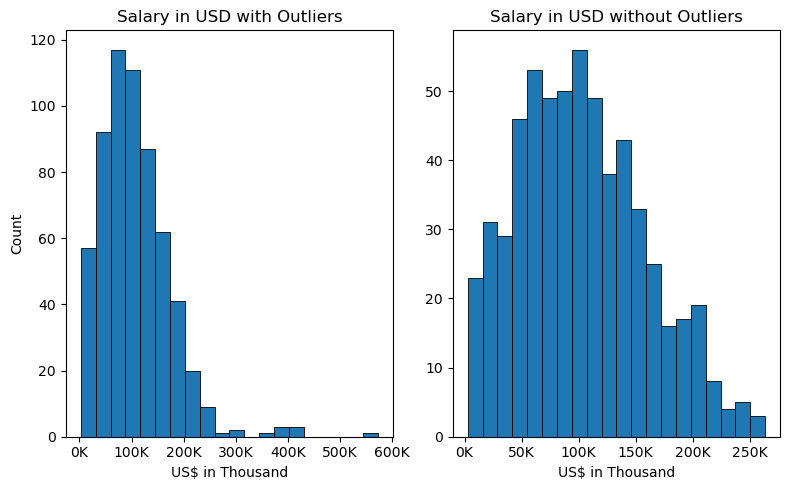

In [290]:
# Difference visualised
import matplotlib.ticker as mticker
fig, ax = plt.subplots(1,2, figsize = (8,5))

ax[0].hist(salaries['Salary_USD'], bins = 20, edgecolor = 'black', linewidth = 0.6)
ax[0].set_title("Salary in USD with Outliers")
ax[0].set_ylabel("Count")
ax[0].set_xlabel("US$ in Thousand")
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

ax[1].hist(no_outliers['Salary_USD'], bins = 20, edgecolor = 'black', linewidth = 0.6)
ax[1].set_title("Salary in USD without Outliers")
ax[1].set_xlabel("US$ in Thousand")
ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()